# Ying Personal EDA and Baseline Modeling

**Research question**: Can building characteristics and energy-use indicators predict ENERGY STAR Score?        

This notebook continues from the shared-cleaned dataset and focuses on three stages:     
1.Personal EDA for the target and selected features    
2.Task-specific preprocessing decisions     
3.Baseline regression modeling

In [240]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

In [194]:
file_path = "NYC_Building_Energy_and_Water_Data_Disclosure_shared_cleaned.csv"
df1 = pd.read_csv(file_path, low_memory=False)

In [195]:
print("Shape:", df1.shape)
print("Columns:", len(df1.columns))

Shape: (103259, 265)
Columns: 265


In [196]:
target = "ENERGY STAR Score"

building_features = [
    "Year Built",
    "Property GFA - Self-Reported (ft²)",
    "Number of Buildings",
    "Occupancy",
    "Primary Property Type - Self Selected",
    "Largest Property Use Type",
    "Largest Property Use Type - Gross Floor Area (ft²)"
]

energy_features = [
    "Electricity Use - Grid Purchase (kBtu)",
    "Natural Gas Use (kBtu)",
    "District Steam Use (kBtu)",
    "District Hot Water Use (kBtu)",
    "Annual Maximum Demand (kW)"
]

selected_features = [c for c in building_features + energy_features if c in df1.columns]

print("Target:", target)
print("Selected features:")
for col in selected_features:
    print("-", col)

Target: ENERGY STAR Score
Selected features:
- Year Built
- Property GFA - Self-Reported (ft²)
- Number of Buildings
- Occupancy
- Primary Property Type - Self Selected
- Largest Property Use Type
- Largest Property Use Type - Gross Floor Area (ft²)
- Electricity Use - Grid Purchase (kBtu)
- Natural Gas Use (kBtu)
- District Steam Use (kBtu)
- District Hot Water Use (kBtu)
- Annual Maximum Demand (kW)


The selected features are intended for preliminary exploratory data analysis. They will be further refined based on missingness, redundancy, and transformation needs before baseline modeling.

## 1. Personal EDA

In [199]:
cols_for_personal_eda = [target] + selected_features
df2 = df1[cols_for_personal_eda].copy()

numeric_features = [
    target,
    "Year Built",
    "Property GFA - Self-Reported (ft²)",
    "Number of Buildings",
    "Occupancy",
    "Largest Property Use Type - Gross Floor Area (ft²)",
    "Electricity Use - Grid Purchase (kBtu)",
    "Natural Gas Use (kBtu)",
    "District Steam Use (kBtu)",
    "District Hot Water Use (kBtu)",
    "Annual Maximum Demand (kW)"
]

numeric_features = [c for c in numeric_features if c in df2.columns]

for col in numeric_features:
    df2[col] = pd.to_numeric(
        df2[col].astype(str).str.replace(",", "", regex=False),
        errors="coerce"
    )

print("Shape of personal EDA data:", df2.shape)
df2.head()

Shape of personal EDA data: (103259, 13)


,ENERGY STAR Score,Year Built,Property GFA - Self-Reported (ft²),Number of Buildings,Occupancy,Primary Property Type - Self Selected,Largest Property Use Type,Largest Property Use Type - Gross Floor Area (ft²),Electricity Use - Grid Purchase (kBtu),Natural Gas Use (kBtu),District Steam Use (kBtu),District Hot Water Use (kBtu),Annual Maximum Demand (kW)
0,96.0,1930,51749.0,1,50,Non-Refrigerated Warehouse,Non-Refrigerated Warehouse,51749.0,70973.0,449200.0,NaN,NaN,NaN
1,61.0,1960,52941.0,1,75,Multifamily Housing,Multifamily Housing,52941.0,1642970.2,1453700.0,NaN,NaN,NaN
2,NaN,1941,35196.0,1,50,Mixed Use Property,Office,17598.0,1395451.2,849365.4,NaN,NaN,NaN
3,64.0,1898,107234.0,1,100,Multifamily Housing,Multifamily Housing,92898.0,2191128.4,5122899.9,NaN,NaN,NaN
4,98.0,1911,75191.0,1,80,Medical Office,Medical Office,71431.0,3711191.8,111000.0,NaN,NaN,NaN


In [200]:
print("Non-missing target count:", df2[target].notna().sum())
print("Missing target count:", df2[target].isna().sum())
print("\nTarget summary:")
print(df2[target].describe())

Non-missing target count: 73377
Missing target count: 29882

Target summary:
count    73377.000000
mean        62.414748
std         29.084765
min          1.000000
25%         42.000000
50%         68.000000
75%         87.000000
max        100.000000
Name: ENERGY STAR Score, dtype: float64


In [201]:
df_model = df2.dropna(subset=[target]).copy()
print("Shape after dropping missing target:", df_model.shape)

Shape after dropping missing target: (73377, 13)


In [204]:
missing_summary = pd.DataFrame({
    "missing_count": df_model[selected_features].isna().sum(),
    "missing_rate": df_model[selected_features].isna().mean()
}).sort_values("missing_rate", ascending=False)

missing_summary

,missing_count,missing_rate
District Hot Water Use (kBtu),73365,0.999836
District Steam Use (kBtu),70092,0.955231
Annual Maximum Demand (kW),68299,0.930796
Natural Gas Use (kBtu),3539,0.048230
Electricity Use - Grid Purchase (kBtu),1039,0.014160
Year Built,0,0.000000
Property GFA - Self-Reported (ft²),0,0.000000
Number of Buildings,0,0.000000
Occupancy,0,0.000000
Primary Property Type - Self Selected,0,0.000000


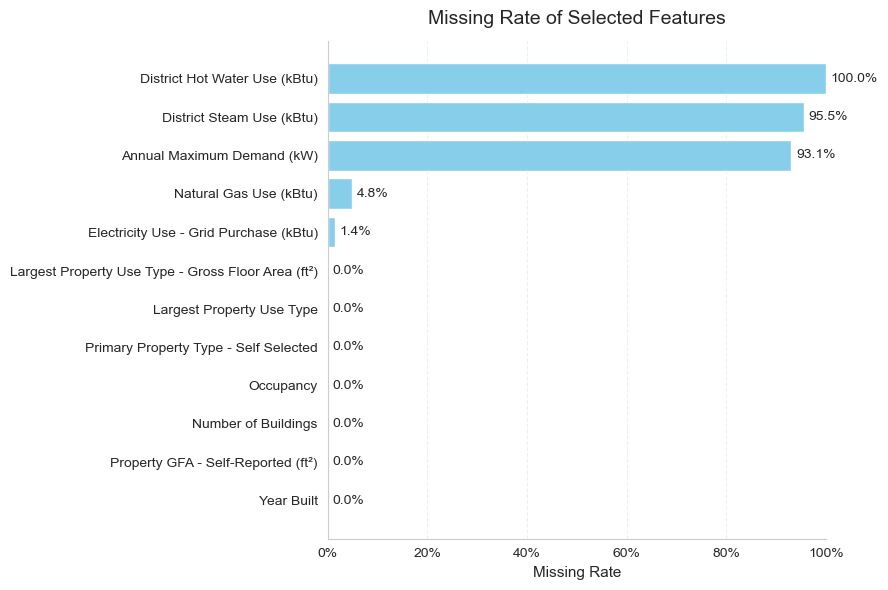

In [206]:
plot_df = missing_summary["missing_rate"].sort_values()

fig, ax = plt.subplots(figsize=(9, 6))

bars = ax.barh(plot_df.index, plot_df.values, color="skyblue")

ax.set_title("Missing Rate of Selected Features", fontsize=14, pad=12)
ax.set_xlabel("Missing Rate", fontsize=11)
ax.set_ylabel("")
ax.set_xlim(0, 1)

ax.xaxis.set_major_formatter(lambda x, pos: f"{x:.0%}")

ax.grid(axis="x", linestyle="--", alpha=0.3)
ax.grid(False, axis="y")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

for bar in bars:
    width = bar.get_width()
    ax.text(width + 0.01,
            bar.get_y() + bar.get_height() / 2,
            f"{width:.1%}",
            va="center",
            fontsize=10)

plt.tight_layout()
plt.show()

In [207]:
high_missing_features = [
    "District Hot Water Use (kBtu)",
    "District Steam Use (kBtu)",
    "Annual Maximum Demand (kW)"
]
df_model = df_model.drop(columns=high_missing_features, errors="ignore")

Because missing values in `Electricity Use - Grid Purchase (kBtu)` and `Natural Gas Use (kBtu)` may reflect non-use or different reporting patterns rather than random omission, missingness indicators are added for both variables before imputation.

In [215]:
df_model["Electricity_missing"] = df_model["Electricity Use - Grid Purchase (kBtu)"].isna().astype(int)
df_model["NaturalGas_missing"] = df_model["Natural Gas Use (kBtu)"].isna().astype(int)

group_col = "Primary Property Type - Self Selected"

# Electricity: group median, then fallback to global median
elec_group_median = df_model.groupby(group_col)["Electricity Use - Grid Purchase (kBtu)"].transform("median")
elec_global_median = df_model["Electricity Use - Grid Purchase (kBtu)"].median()

df_model["Electricity Use - Grid Purchase (kBtu)"] = (
    df_model["Electricity Use - Grid Purchase (kBtu)"]
    .fillna(elec_group_median)
    .fillna(elec_global_median)
)

# Natural gas: option 1 = group median, then fallback
gas_group_median = df_model.groupby(group_col)["Natural Gas Use (kBtu)"].transform("median")
gas_global_median = df_model["Natural Gas Use (kBtu)"].median()

df_model["Natural Gas Use (kBtu)"] = (
    df_model["Natural Gas Use (kBtu)"]
    .fillna(gas_group_median)
    .fillna(gas_global_median)
)
df_model.head(10)

,ENERGY STAR Score,Year Built,Property GFA - Self-Reported (ft²),Number of Buildings,Occupancy,Primary Property Type - Self Selected,Largest Property Use Type,Largest Property Use Type - Gross Floor Area (ft²),Electricity Use - Grid Purchase (kBtu),Natural Gas Use (kBtu),Electricity_missing,NaturalGas_missing
0,96.0,1930,51749.0,1,50,Non-Refrigerated Warehouse,Non-Refrigerated Warehouse,51749.0,70973.0,449200.0,0,0
1,61.0,1960,52941.0,1,75,Multifamily Housing,Multifamily Housing,52941.0,1642970.2,1453700.0,0,0
3,64.0,1898,107234.0,1,100,Multifamily Housing,Multifamily Housing,92898.0,2191128.4,5122899.9,0,0
4,98.0,1911,75191.0,1,80,Medical Office,Medical Office,71431.0,3711191.8,111000.0,0,0
5,61.0,1935,68400.0,1,80,Multifamily Housing,Multifamily Housing,68400.0,703117.6,5199600.0,0,0
6,83.0,1984,89902.0,1,80,Office,Office,89902.0,1579179.3,3297099.7,0,0
7,58.0,1986,63240.0,1,100,Non-Refrigerated Warehouse,Non-Refrigerated Warehouse,63240.0,860677.0,1099100.0,0,0
8,16.0,1937,82576.0,1,100,Multifamily Housing,Multifamily Housing,82576.0,1135718.3,8852599.8,0,0
9,71.0,1933,136000.0,1,100,Multifamily Housing,Multifamily Housing,136000.0,1596587.4,8681600.0,0,0
10,37.0,1942,127200.0,1,100,Multifamily Housing,Multifamily Housing,127200.0,1773356.3,10725000.1,0,0


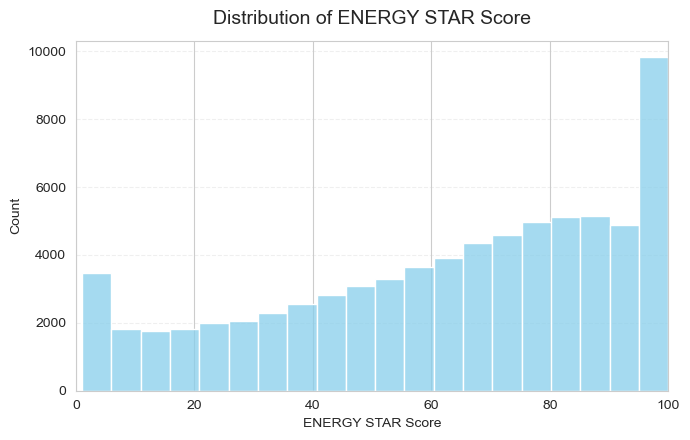

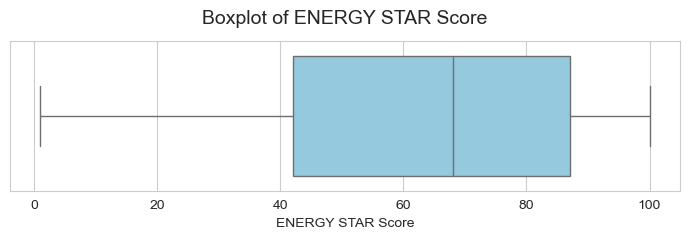

In [217]:
plt.figure(figsize=(7, 4.5))
sns.histplot(df_model[target].dropna(), bins=20, color="skyblue")

plt.title("Distribution of ENERGY STAR Score", fontsize=14, pad=12)
plt.xlabel("ENERGY STAR Score")
plt.ylabel("Count")
plt.xlim(0, 100)
plt.grid(axis="y", linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 2.5))
sns.boxplot(x=df_model[target].dropna(), color="skyblue")
plt.title("Boxplot of ENERGY STAR Score", fontsize=14, pad=12)
plt.xlabel("ENERGY STAR Score")
plt.tight_layout()
plt.show()

The ENERGY STAR scores are well distributed across the 1–100 range, providing enough variance for a solid regression model. The distribution is visibly skewed toward higher scores, with far fewer buildings at the low end. We also see a significant cluster at the 100 mark, pointing to a ceiling effect among top-tier performers. Because the median sits above the mean, it’s clear that the lower scoring outliers are dragging the average down. While the variable is a good candidate for modeling, the density of observations at the maximum score might make it tricky for the model to differentiate between the absolute best-performing buildings.

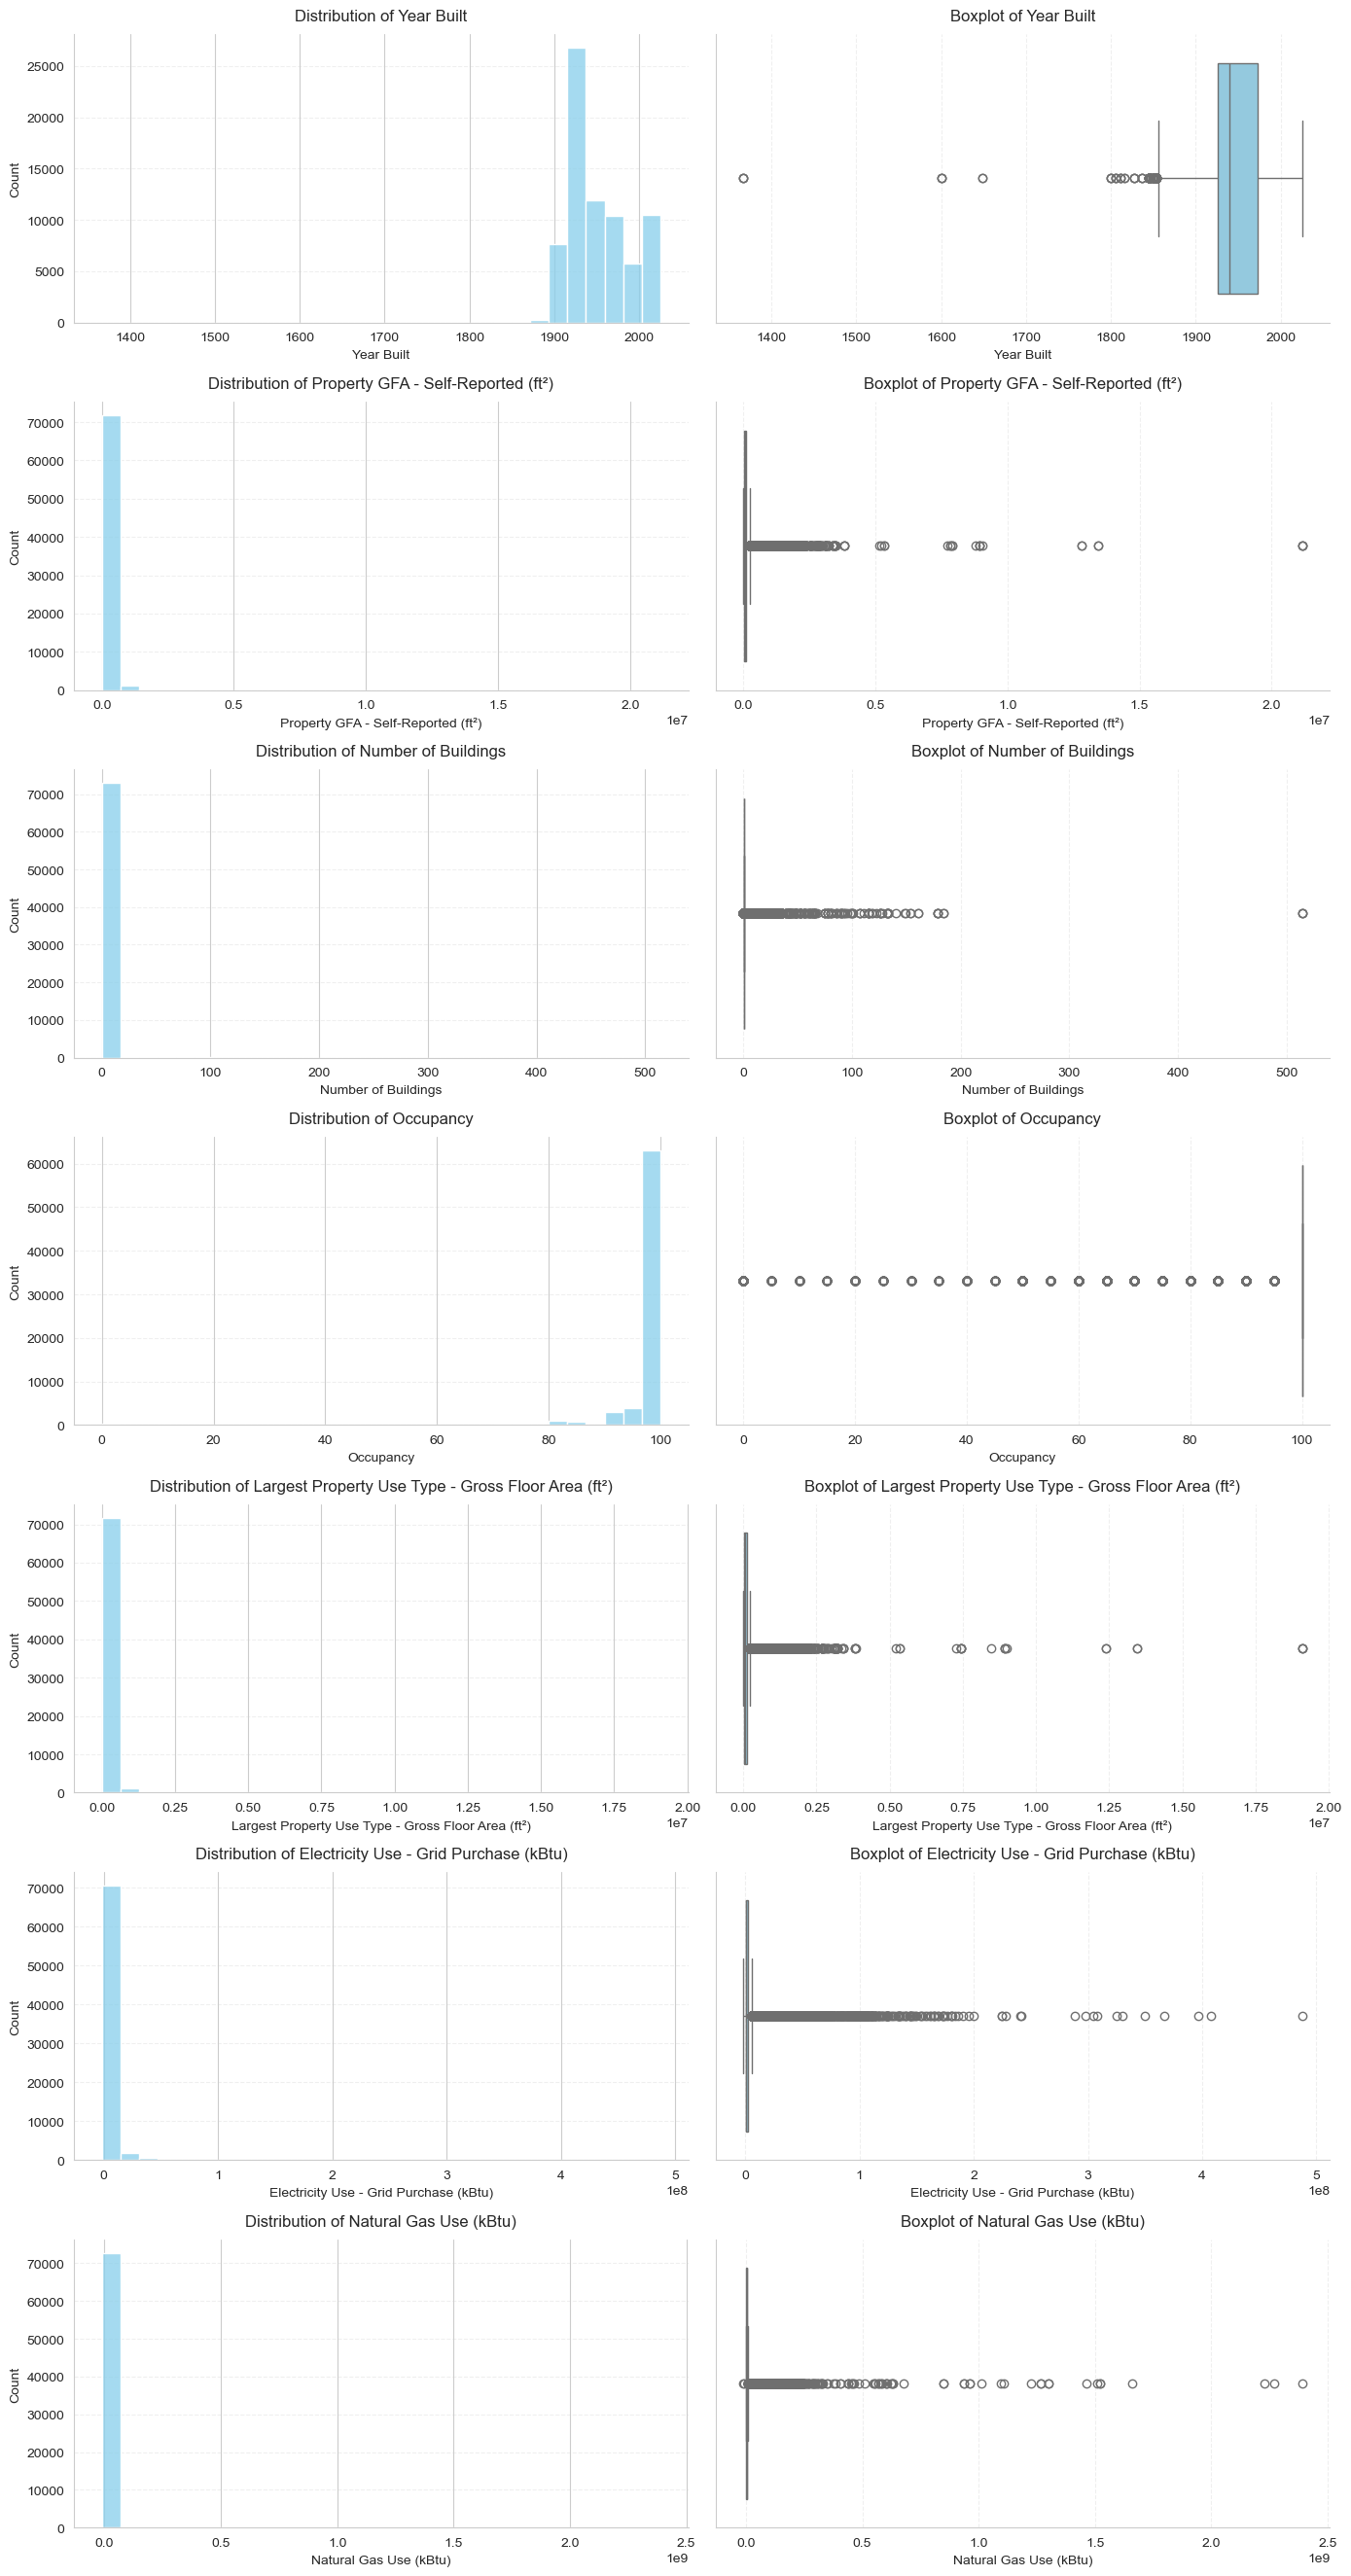

In [220]:
numeric_features_after = [
    "Year Built",
    "Property GFA - Self-Reported (ft²)",
    "Number of Buildings",
    "Occupancy",
    "Largest Property Use Type - Gross Floor Area (ft²)",
    "Electricity Use - Grid Purchase (kBtu)",
    "Natural Gas Use (kBtu)"
]

numeric_features_after = [col for col in numeric_features_after if col in df_model.columns]

n_rows = len(numeric_features_after)

fig, axes = plt.subplots(n_rows, 2, figsize=(14, 3.8 * n_rows))

# in case there is only one feature
if n_rows == 1:
    axes = [axes]

for i, col in enumerate(numeric_features_after):
    data = df_model[col].dropna()

    # left: distribution
    sns.histplot(data, bins=30, color="skyblue", ax=axes[i][0])
    axes[i][0].set_title(f"Distribution of {col}", fontsize=12, pad=10)
    axes[i][0].set_xlabel(col)
    axes[i][0].set_ylabel("Count")
    axes[i][0].grid(axis="y", linestyle="--", alpha=0.3)
    axes[i][0].spines["top"].set_visible(False)
    axes[i][0].spines["right"].set_visible(False)

    # right: boxplot
    sns.boxplot(x=data, color="skyblue", ax=axes[i][1])
    axes[i][1].set_title(f"Boxplot of {col}", fontsize=12, pad=10)
    axes[i][1].set_xlabel(col)
    axes[i][1].set_ylabel("")
    axes[i][1].grid(axis="x", linestyle="--", alpha=0.3)
    axes[i][1].spines["top"].set_visible(False)
    axes[i][1].spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

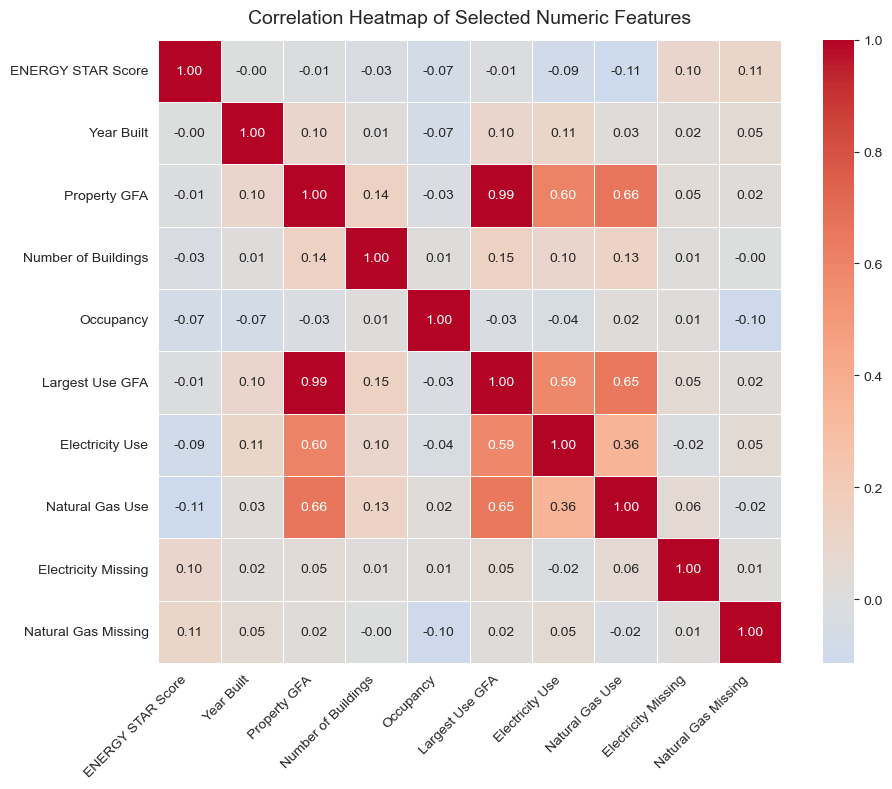

In [221]:
corr_features = [
    "ENERGY STAR Score",
    "Year Built",
    "Property GFA - Self-Reported (ft²)",
    "Number of Buildings",
    "Occupancy",
    "Largest Property Use Type - Gross Floor Area (ft²)",
    "Electricity Use - Grid Purchase (kBtu)",
    "Natural Gas Use (kBtu)",
    "Electricity_missing",
    "NaturalGas_missing"
]

corr_features = [col for col in corr_features if col in df_model.columns]

label_map = {
    "ENERGY STAR Score": "ENERGY STAR Score",
    "Year Built": "Year Built",
    "Property GFA - Self-Reported (ft²)": "Property GFA",
    "Number of Buildings": "Number of Buildings",
    "Occupancy": "Occupancy",
    "Largest Property Use Type - Gross Floor Area (ft²)": "Largest Use GFA",
    "Electricity Use - Grid Purchase (kBtu)": "Electricity Use",
    "Natural Gas Use (kBtu)": "Natural Gas Use",
    "Electricity_missing": "Electricity Missing",
    "NaturalGas_missing": "Natural Gas Missing"
}

corr_df = df_model[corr_features].corr()
corr_df = corr_df.rename(index=label_map, columns=label_map)

plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_df,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.5
)
plt.title("Correlation Heatmap of Selected Numeric Features", fontsize=14, pad=12)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

`Property GFA - Self-Reported (ft²)` and `Largest Property Use Type - Gross Floor Area (ft²)` were highly correlated, indicating substantial redundancy. I retained Largest Property Use Type - Gross Floor Area (ft²) because it aligns more directly with Largest Property Use Type and better reflects the size of the property’s dominant use category.

In [225]:
df_model = df_model.drop(columns=["Property GFA - Self-Reported (ft²)"], errors="ignore")

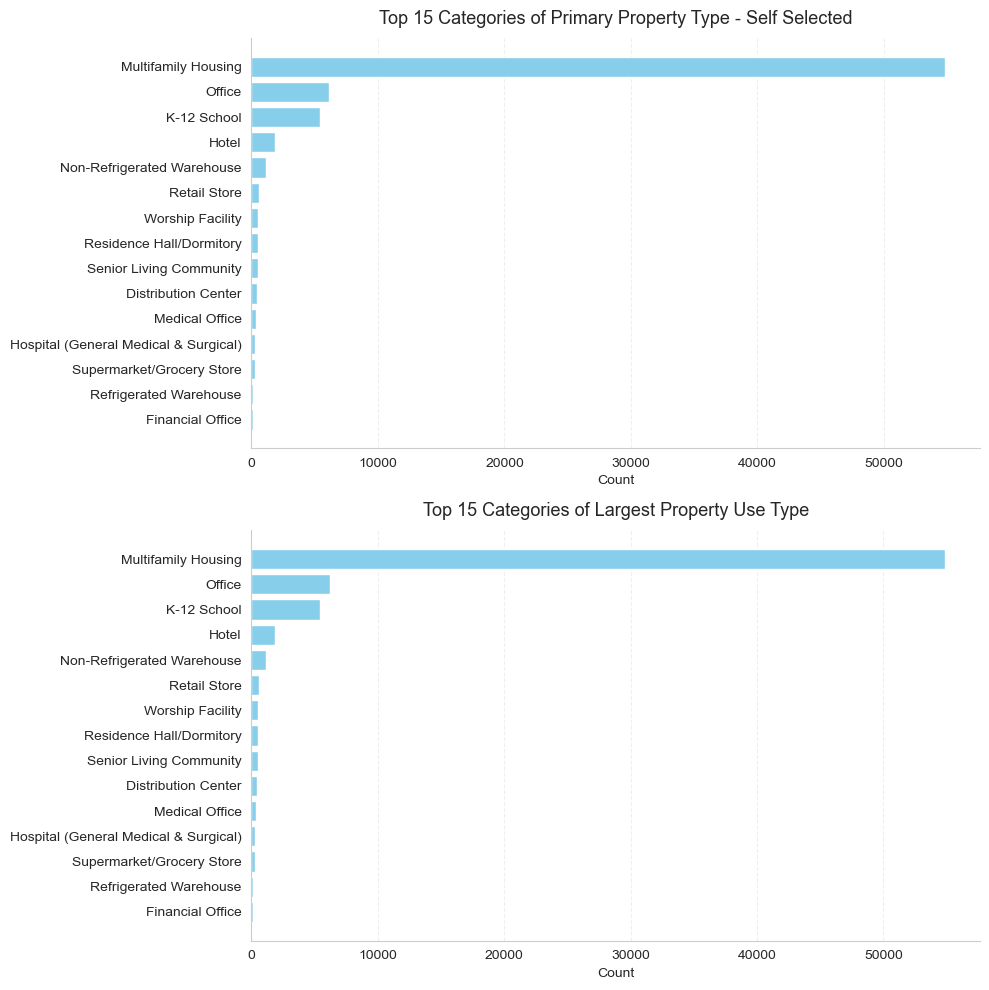

In [227]:
categorical_features_after = [
    "Primary Property Type - Self Selected",
    "Largest Property Use Type"
]

categorical_features_after = [col for col in categorical_features_after if col in df_model.columns]

top_n = 15
n_rows = len(categorical_features_after)

fig, axes = plt.subplots(n_rows, 1, figsize=(10, 5 * n_rows))

if n_rows == 1:
    axes = [axes]

for i, col in enumerate(categorical_features_after):
    count_series = df_model[col].value_counts().head(top_n).sort_values()

    axes[i].barh(count_series.index, count_series.values, color="skyblue")
    axes[i].set_title(f"Top {top_n} Categories of {col}", fontsize=13, pad=10)
    axes[i].set_xlabel("Count")
    axes[i].set_ylabel("")
    axes[i].grid(False, axis="y")
    axes[i].grid(axis="x", linestyle="--", alpha=0.3)
    axes[i].spines["top"].set_visible(False)
    axes[i].spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

In [229]:
df3 = df_model[["Primary Property Type - Self Selected", "Largest Property Use Type"]].copy()
same_mask = df3["Primary Property Type - Self Selected"] == df3["Largest Property Use Type"]
print("Same count:", same_mask.sum())
print("Different count:", (~same_mask).sum())
print(f"Same rate: {same_mask.mean():.2%}")
print(f"Different rate: {(~same_mask).mean():.2%}")

Same count: 73218
Different count: 159
Same rate: 99.78%
Different rate: 0.22%


`Primary Property Type - Self Selected` and `Largest Property Use Type` were nearly identical in this dataset, with 99.78% of observations having the same value in both fields. To reduce redundancy, only one of the two variables was retained. I chose `Largest Property Use Type` because it more directly reflects the dominant use category of the property by gross floor area.

In [231]:
df_model = df_model.drop(columns="Primary Property Type - Self Selected", errors="ignore")
df_model.columns

Index(['ENERGY STAR Score', 'Year Built', 'Number of Buildings', 'Occupancy',
       'Largest Property Use Type',
       'Largest Property Use Type - Gross Floor Area (ft²)',
       'Electricity Use - Grid Purchase (kBtu)', 'Natural Gas Use (kBtu)',
       'Electricity_missing', 'NaturalGas_missing'],
      dtype='object')

## 2. Preprocessing Setup

In [242]:
final_features = [
    "Year Built",
    "Number of Buildings",
    "Occupancy",
    "Largest Property Use Type",
    "Largest Property Use Type - Gross Floor Area (ft²)",
    "Electricity Use - Grid Purchase (kBtu)",
    "Natural Gas Use (kBtu)"
]
final_features = [col for col in final_features if col in df_model.columns]
X = df_model[final_features].copy()
y = df_model[target].copy()

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (73377, 7)
y shape: (73377,)


In [248]:
numeric_features_model = [
    "Year Built",
    "Number of Buildings",
    "Occupancy",
    "Largest Property Use Type - Gross Floor Area (ft²)",
    "Electricity Use - Grid Purchase (kBtu)",
    "Natural Gas Use (kBtu)",
    "Electricity_missing",
    "NaturalGas_missing"
]

numeric_features_model = [col for col in numeric_features_model if col in X.columns]
categorical_features_model = ["Largest Property Use Type"]
categorical_features_model = [col for col in categorical_features_model if col in X.columns]

In [250]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
numeric_transformer = Pipeline(steps=[
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features_model),
        ("cat", categorical_transformer, categorical_features_model)
    ]
)

preprocessor

,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,copy,True
,with_mean,True
,with_std,True


## 3. Baseline Models

In [256]:
models = {
    "DummyRegressor": DummyRegressor(strategy="mean"),
    "LinearRegression": LinearRegression(),
    "Ridge": Ridge(alpha=1.0),
    "RandomForestRegressor": RandomForestRegressor(
        n_estimators=200,
        random_state=42,
        n_jobs=-1,
        min_samples_leaf=2,
    ),
}

In [258]:
results = []
fitted_pipelines = {}
predictions = {}

for name, model in models.items():
    pipeline = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)

    results.append({
        "Model": name,
        "MAE": mean_absolute_error(y_test, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_test, y_pred)),
        "R2": r2_score(y_test, y_pred)
    })

    fitted_pipelines[name] = pipeline
    predictions[name] = y_pred

results_df = pd.DataFrame(results).sort_values("RMSE").reset_index(drop=True)
results_df

,Model,MAE,RMSE,R2
0,RandomForestRegressor,11.722713,16.312204,0.678893
1,LinearRegression,23.251092,27.915839,0.059571
2,Ridge,23.255907,27.924326,0.058999
3,DummyRegressor,24.336083,28.791649,-0.000363


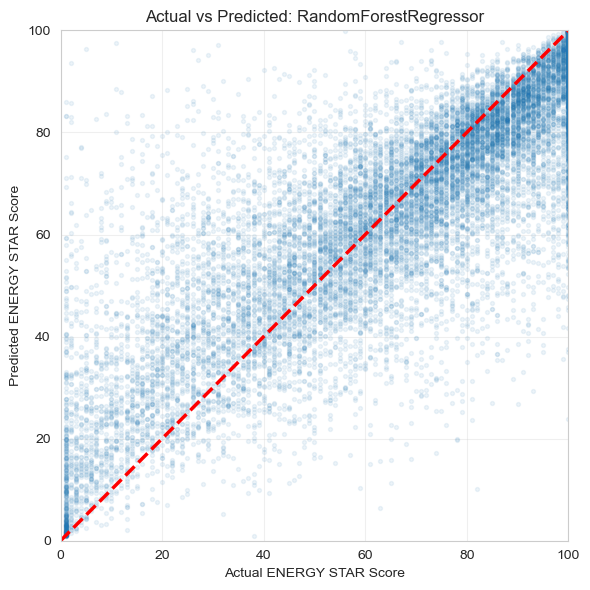

In [268]:
best_model_name = results_df.loc[0, "Model"]
best_pred = predictions[best_model_name]

plt.figure(figsize=(6, 6))
plt.scatter(y_test, best_pred, alpha=0.08, s=8)
plt.plot([0, 100], [0, 100], color="red", linewidth=2.5, linestyle="--")

plt.xlim(0, 100)
plt.ylim(0, 100)
plt.xlabel("Actual ENERGY STAR Score")
plt.ylabel("Predicted ENERGY STAR Score")
plt.title(f"Actual vs Predicted: {best_model_name}")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 4. Current Findings

1. The selected variables seem to have real predictive value for ENERGY STAR Score.
2. Some features were redundant, so simplifying the variable set was necessary.
3. The baseline results show that nonlinear models work much better than linear ones.

## 5. Next Steps

1. The first next step is to improve feature engineering.
2. The next step is to tune the stronger models instead of only comparing default baseline versions.
3. It is also important to evaluate where the model performs well and where it still struggles.